## Assignment 5

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt
import seaborn as sns
import uuid

In [6]:
#Set a random seed
np.random.seed(42)

In [9]:
#Load the dataset
data_path = "/Users/vladgappasov/Downloads/archive/Wednesday-workingHours.pcap_ISCX.csv"
df= pd.read_csv(data_path)

In [10]:
#Select a random subset of 5000 rows
sizeofsubset= np.random.randint(5000, 8001)
df_subset= df.sample(n=sizeofsubset, random_state=42)

In [11]:
#Data Clean
#Strip any whitespace from the column rows.
df_subset.columns= df_subset.columns.str.strip()

In [12]:
#Drop columns with any and all NaN values or any constant values.
df_subset= df_subset.dropna(axis=1, how='all')
df_subset= df_subset.loc[:, (df_subset != df_subset.iloc[0]).any()]

In [14]:
#Replace any infinite values with NaN and drop any rows that have NaN
df_subset.replace([np.inf, -np.inf], np.nan, inplace=True)
df_subset.dropna(inplace=True)

In [28]:
#Select numerical featuers that are relevant for anomaly detection
thefeatures= [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Fwd Packet Length Mean', 'Bwd Packet Length Mean','Flow Bytes/s', 'Flow Packets/s', 'Fwd IAT Total', 'Bwd IAT Total'
]

In [30]:
#Ensure selected featuers that exist in the dataset.
thefeatures= [col for col in thefeatures if col in df_subset.columns]
if not thefeatures:
    raise ValueError("Sorry, but there were no valid features found in the dataset.")
X = df_subset[thefeatures]
X = df_subset[thefeatures]

In [20]:
#Now, Standardize the features.
thescaler= StandardScaler()
X_scaled= thescaler.fit_transform(X)

In [45]:
#Technique 1: Isolation Forest
Isol_Forest= IsolationForest(contamination=0.1, random_state=42)
Isol_Labels= Isol_Forest.fit_predict(X_scaled)
df_subset['Isol_Forest_Anomaly'] = Isol_Labels

<Axes: xlabel='Flow Duration', ylabel='Total Fwd Packets'>

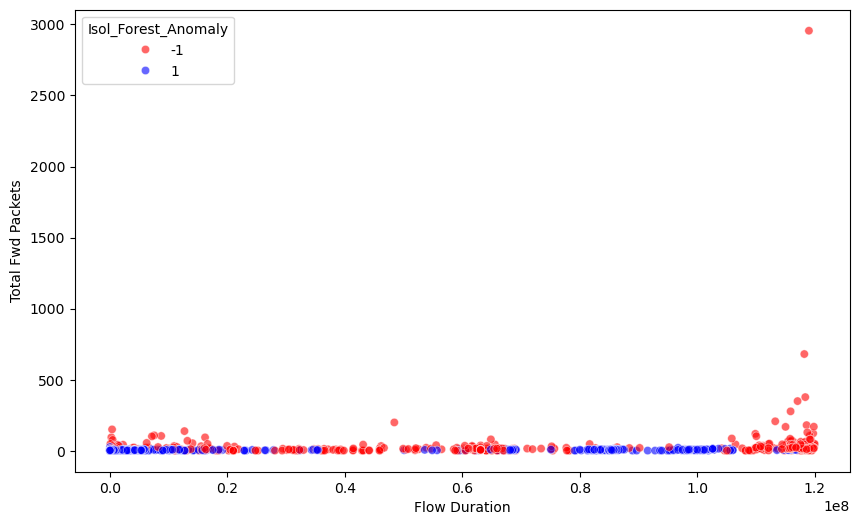

In [46]:
#Visualization: Scatter plot of 2 features that have anomaly labels.
plt.figure(figsize=(10,6))
sns.scatterplot(
x=X['Flow Duration'], y=X['Total Fwd Packets'],
    hue=df_subset['Isol_Forest_Anomaly'], palette={1: 'blue', -1: 'red'},
    alpha=0.6
)

In [47]:
plt.title('Isolation Forest Anomaly: Flow Duration vs The Total Forward Packets')
plt.xlabel('Flow Duration(msecs)')
plt.ylabel('The Total Forwarded Packets')
plt.savefig('Isol_Forest_Anomaly.png')
plt.close()

In [48]:
#Extract and then show the 3 examples of anomalies(common for both methods)
Anomalies= df_subset[(df_subset['Isol_Forest_Anomaly']== -1) & (df_subset['LOF_Anomaly'] == -1)]
Anomaly_Exs= Anomalies.head(3)

In [44]:
#Print the anomaly ex's
print("\n The Anomaly Detection: Results")


 The Anomaly Detection: Results


In [57]:
print(f"Total records in subset: {len(df_subset)}")
print(f"The Number of anomalies that are detected in Isolation Forest: {(df_subset['Isol_Forest_Anomaly'] == -1).sum()}")
print(f"The Number of anomalies that was detected or found by the LOF: {(df_subset['LOF_Anomaly'] == -1).sum()}")
print(f"The Common anomalies(of both methods are): {len(Anomalies)}")


print("\n The 3 Example Anomalies: ")
for idx, row in Anomaly_Exs.iterrows():
    print(f"\n The Anomaly at the index {idx}:")
    print(f"\n The Flow Duration: {row['Flow Duration']} msecs")
    print(f" The Total Forwarded Packets are: {row['Total Fwd Packets']}")
    print(f"The Total Backward Packets: {row['Total Backward Packets']}")
    print(f" The Flow Bytes are/s: {row['Flow Bytes/s']}")
    print("Why is this suspicious?:")
    if row['Flow Duration'] > df_subset['Flow Duration'].quantile(0.95):
        print("ALERT: This is a very long flow duration, suggesting the potential scanning or persistent attack.")
    if row['Flow Bytes/s'] > df_subset['Flow Bytes/s'].quantile(0.95):
        print("ALERT: This is a very high amount of bytes per second, indicating that this is a possible data exfiltration or DoS attempt.")
    if row['Total Fwd Packets'] > df_subset['Total Fwd Packets'].quantile(0.95):
        print("ALERT: There is a very high number of forward packets, and this shows that this is possibly a flooding attack.")

Total records in subset: 5847
The Number of anomalies that are detected in Isolation Forest: 585
The Number of anomalies that was detected or found by the LOF: 585
The Common anomalies(of both methods are): 585

 The 3 Example Anomalies: 

 The Anomaly at the index 489500:

 The Flow Duration: 111949370 msecs
 The Total Forwarded Packets are: 13
The Total Backward Packets: 13
 The Flow Bytes are/s: 33.5687463
Why is this suspicious?:
ALERT: This is a very long flow duration, suggesting the potential scanning or persistent attack.

 The Anomaly at the index 48318:

 The Flow Duration: 116145841 msecs
 The Total Forwarded Packets are: 21
The Total Backward Packets: 20
 The Flow Bytes are/s: 34.43945961
Why is this suspicious?:
ALERT: This is a very long flow duration, suggesting the potential scanning or persistent attack.
ALERT: There is a very high number of forward packets, and this shows that this is possibly a flooding attack.

 The Anomaly at the index 365360:

 The Flow Duration: 